# 02_coverage_matrix.ipynb
**Author:** Emma McCallum  
**Purpose:** Build a coverage matrix showing which BEGES P-categories contain positive reported values and which return zero in the structured ADEME export.  
**Input:** `data/processed/emissions_long.csv`  
**Output:** `figures/coverage_heatmap.png`, `data/processed/coverage_matrix.csv`, 
`data/processed/coverage_summary.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## The central question: reported, zero, or missing?

When a firm submits a BEGES report, each P-category can be in one of three states:

| State    | What it means |
|----------|---------------|
| Reported | The firm submitted a positive value (> 0 tCO2e) |
| Zero     | The firm submitted exactly zero |
| Missing  | No value was submitted for this category |

Zero and missing look identical in a bar chart: both contribute nothing to the total.
But analytically they are very different.

A firm that reports zero in P3.2 (business travel) has at least assessed that category
and concluded it is negligible. A firm that leaves P3.2 blank may simply have ignored it.

For professional services firms, the recommended categories (P3 through P6) are where
most of the real emissions sit. That is also exactly where coverage gaps are most likely.
This matrix makes those gaps visible.

**Limitation:** The ADEME export does not always distinguish a genuine zero from a blank
that the platform converted to zero at export time. Where this ambiguity exists, we flag
it in the methodology audit (NB03).

In [2]:
df = pd.read_csv("../data/processed/emissions_long.csv")

print(f"Rows: {len(df)}")
print(f"Firms: {df['Raison sociale'].nunique()}")
print(f"Categories: {df['beges_category'].nunique()}")
print()
print(df.head(10))

Rows: 110
Firms: 5
Categories: 22

                Raison sociale  Année de reporting beges_category    tco2e  \
0                 ANTEA FRANCE                2023           P1.1   104.30   
1                      ARTELIA                2022           P1.1     5.00   
2  BUREAU VERITAS EXPLOITATION                2023           P1.1     0.00   
3                   ECOCERT SA                2024           P1.1     0.00   
4                      Eco CO2                2023           P1.1    13.11   
5                 ANTEA FRANCE                2023           P1.2  1820.50   
6                      ARTELIA                2022           P1.2  3088.00   
7  BUREAU VERITAS EXPLOITATION                2023           P1.2   136.00   
8                   ECOCERT SA                2024           P1.2   565.30   
9                      Eco CO2                2023           P1.2    13.31   

     scope regulatory_status  
0  Scope 1         Mandatory  
1  Scope 1         Mandatory  
2  Scope 1   

In [3]:
print(f"\nNaN values in tco2e: {df['tco2e'].isna().sum()}")


NaN values in tco2e: 0


In [4]:
pivot = df.pivot_table(
    index="beges_category",
    columns="Raison sociale",
    values="tco2e",
    aggfunc="first"
)

print(pivot.to_string())

Raison sociale  ANTEA FRANCE  ARTELIA  BUREAU VERITAS EXPLOITATION  ECOCERT SA  Eco CO2
beges_category                                                                         
P1.1                   104.3      5.0                          0.0         0.0    13.11
P1.2                  1820.5   3088.0                        136.0       565.3    13.31
P1.3                     0.0      0.0                          0.0         0.0     0.00
P1.4                     0.0    272.0                         94.0         0.0     0.00
P1.5                     0.0      0.0                          0.0         0.0     0.00
P2.1                    44.4    649.0                          0.0        12.1     0.31
P2.2                     0.0    332.0                          0.0         0.0     1.11
P3.1                    11.5      0.0                          0.0        90.4     0.15
P3.2                     0.0      0.0                          0.0         0.0     0.00
P3.3                   552.9   5

## Data reality check: why two states, not three

Before building the classification, the ADEME export was checked for missing values
preserved as NaN.

Result: zero NaN values in tco2e across all 110 rows.

The ADEME platform converts every empty field to zero at export time. A genuine zero
and a blank field that the platform converted are indistinguishable in the structured
data. A three-state classification (Reported / Zero / Missing) would imply a precision
the data does not support.

Two states are used instead:

| State    | Condition    | What it means |
|----------|--------------|---------------|
| Reported | tco2e > 0    | A positive value was submitted |
| Zero     | tco2e == 0.0 | No positive value in the export. Could be a genuine zero or a blank the platform converted |

The pivot table shows that reported emissions are not evenly distributed across
BEGES categories. Some firms report positive values across many categories, while
others report high total emissions concentrated in only a few. This distinction
matters because a high reported Scope 3 equivalent share does not necessarily imply
broad or complete indirect emissions coverage. Notebook 02 evaluates both emissions
magnitude and reporting coverage, while Notebook 03 will examine whether zero values
reflect genuine non-applicability, omitted categories, or limitations in the
structured export.

In [5]:
def classify_coverage(val):
    if val > 0:
        return "Reported"
    else:
        return "Zero"

df["coverage"] = df["tco2e"].apply(classify_coverage)

print(df["coverage"].value_counts())
print()
print(df.groupby(["Raison sociale", "coverage"]).size().unstack(fill_value=0))

coverage
Zero        57
Reported    53
Name: count, dtype: int64

coverage                     Reported  Zero
Raison sociale                             
ANTEA FRANCE                       11    11
ARTELIA                            10    12
BUREAU VERITAS EXPLOITATION         7    15
ECOCERT SA                         11    11
Eco CO2                            14     8


## Classification results

Across all 110 firm and category combinations, 57 return zero and 53 return a
positive value. More than half the available categories carry no reported emissions.

Coverage by firm:

| Firm | Reported | Zero | Total categories |
|------|----------|------|-----------------|
| Eco CO2 | 14 | 8 | 22 |
| Antea France | 11 | 11 | 22 |
| Ecocert SA | 11 | 11 | 22 |
| Artelia | 10 | 12 | 22 |
| Bureau Veritas | 7 | 15 | 22 |

Eco CO2 is the most comprehensive reporter despite being the smallest firm in the
dataset. Bureau Veritas reports the fewest positive categories despite having
significant total emissions concentrated in P4.1 and P4.5.

A high total emissions figure does not imply broad category coverage. The firm with
the highest reported Scope 3 equivalent share is not necessarily the most thorough
reporter. This distinction is central to the audit logic developed across NB02 and NB03.

In [6]:
# Build pivot for heatmap
# Convert coverage labels to numbers so seaborn can colour them
coverage_num = df.pivot_table(
    index="beges_category",
    columns="Raison sociale",
    values="tco2e",
    aggfunc="first"
)

# Replace values with 1 (Reported) or 0 (Zero)
coverage_num = coverage_num.map(lambda x: 1 if x > 0 else 0)

print(coverage_num)

Raison sociale  ANTEA FRANCE  ARTELIA  BUREAU VERITAS EXPLOITATION  \
beges_category                                                       
P1.1                       1        1                            0   
P1.2                       1        1                            1   
P1.3                       0        0                            0   
P1.4                       0        1                            1   
P1.5                       0        0                            0   
P2.1                       1        1                            0   
P2.2                       0        1                            0   
P3.1                       1        0                            0   
P3.2                       0        0                            0   
P3.3                       1        1                            1   
P3.4                       0        0                            0   
P3.5                       1        1                            0   
P4.1                

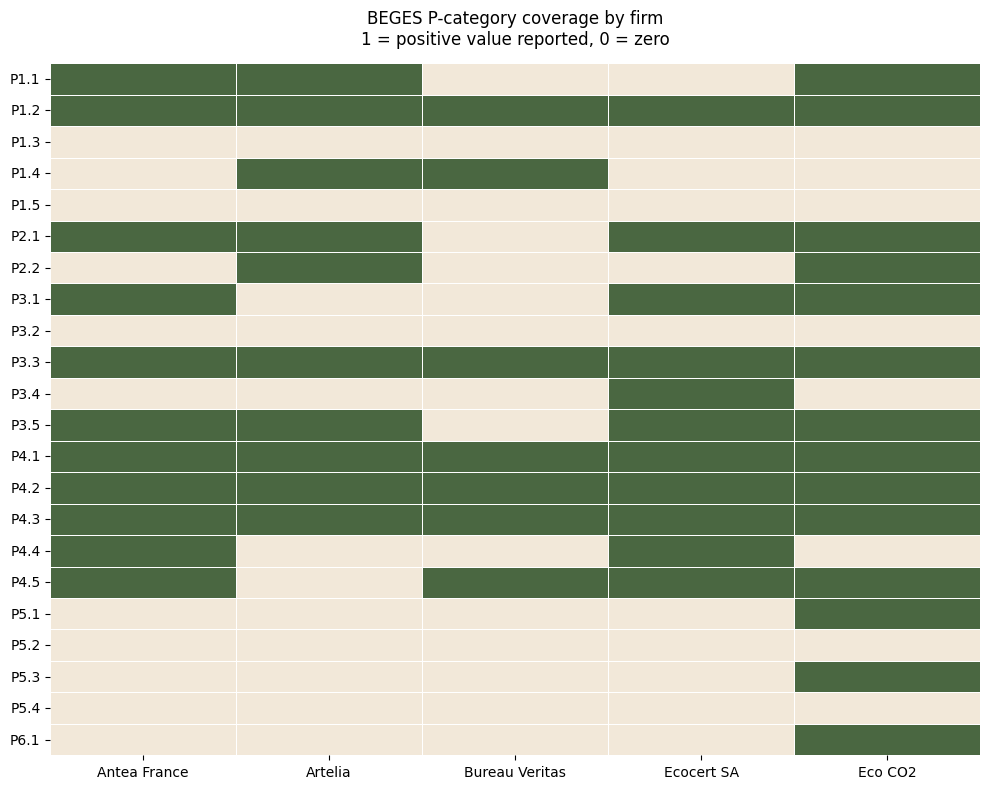

Saved.


In [7]:
# Shorten firm names for the chart
name_map = {
    "BUREAU VERITAS EXPLOITATION": "Bureau Veritas",
    "ANTEA FRANCE": "Antea France",
    "ARTELIA": "Artelia",
    "ECOCERT SA": "Ecocert SA",
    "Eco CO2": "Eco CO2",
}
coverage_num.columns = coverage_num.columns.map(name_map)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    coverage_num,
    ax=ax,
    cmap=["#f2e8d9", "#4a6741"],
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    annot=False,
)

ax.set_title(
    "BEGES P-category coverage by firm\n1 = positive value reported, 0 = zero",
    fontsize=12,
    pad=14,
)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("../figures/coverage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

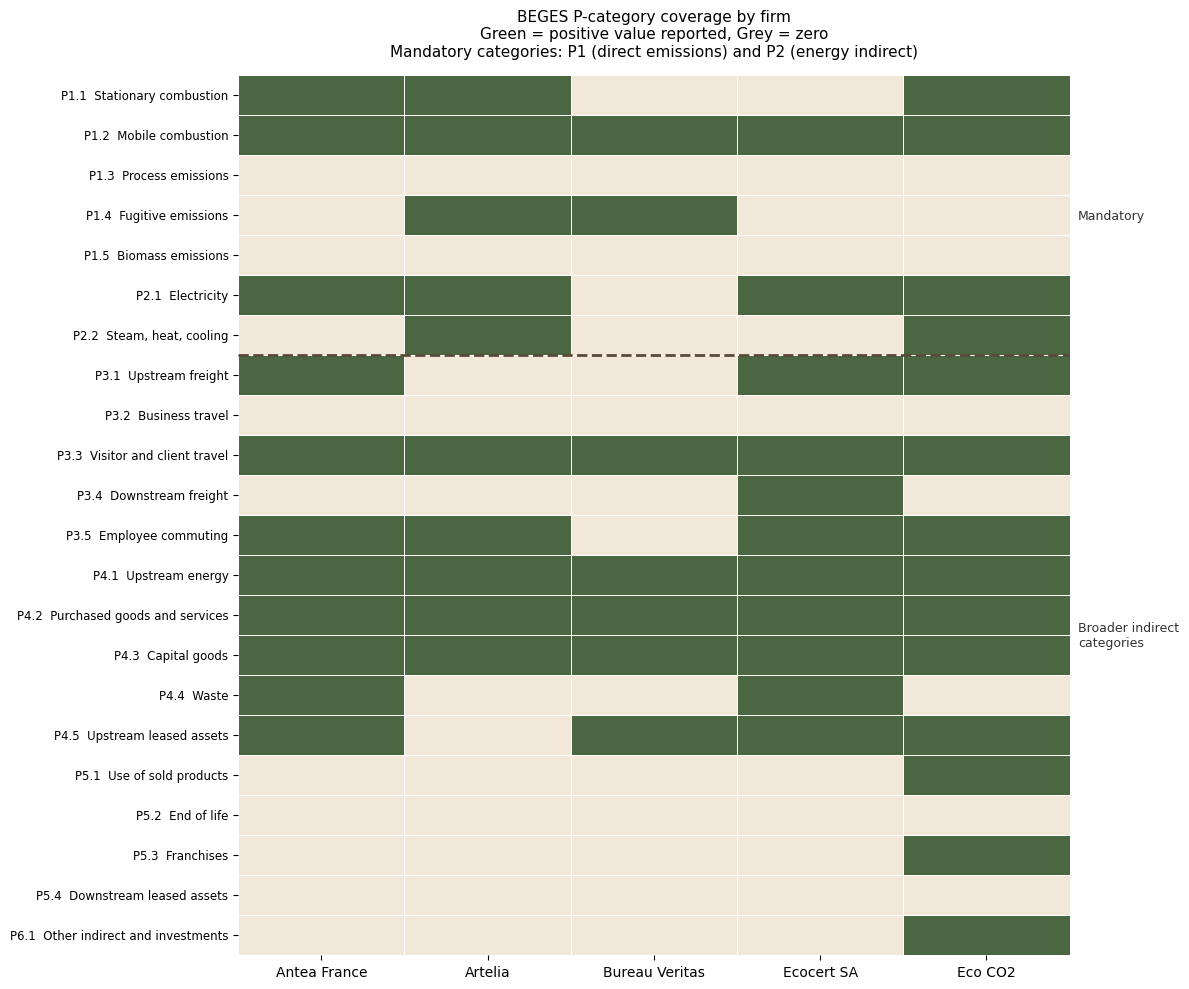

Saved.


In [8]:
label_map = {
    "P1.1": "P1.1  Stationary combustion",
    "P1.2": "P1.2  Mobile combustion",
    "P1.3": "P1.3  Process emissions",
    "P1.4": "P1.4  Fugitive emissions",
    "P1.5": "P1.5  Biomass emissions",
    "P2.1": "P2.1  Electricity",
    "P2.2": "P2.2  Steam, heat, cooling",
    "P3.1": "P3.1  Upstream freight",
    "P3.2": "P3.2  Business travel",
    "P3.3": "P3.3  Visitor and client travel",
    "P3.4": "P3.4  Downstream freight",
    "P3.5": "P3.5  Employee commuting",
    "P4.1": "P4.1  Upstream energy",
    "P4.2": "P4.2  Purchased goods and services",
    "P4.3": "P4.3  Capital goods",
    "P4.4": "P4.4  Waste",
    "P4.5": "P4.5  Upstream leased assets",
    "P5.1": "P5.1  Use of sold products",
    "P5.2": "P5.2  End of life",
    "P5.3": "P5.3  Franchises",
    "P5.4": "P5.4  Downstream leased assets",
    "P6.1": "P6.1  Other indirect and investments",
}

name_map = {
    "BUREAU VERITAS EXPLOITATION": "Bureau Veritas",
    "ANTEA FRANCE": "Antea France",
    "ARTELIA": "Artelia",
    "ECOCERT SA": "Ecocert SA",
    "Eco CO2": "Eco CO2",
}

# Rebuild from scratch to avoid conflicts
coverage_num = df.pivot_table(
    index="beges_category",
    columns="Raison sociale",
    values="tco2e",
    aggfunc="first"
)
coverage_num = coverage_num.map(lambda x: 1 if x > 0 else 0)
coverage_num.columns = coverage_num.columns.map(name_map)
coverage_num.index = coverage_num.index.map(label_map)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    coverage_num,
    ax=ax,
    cmap=["#f2e8d9", "#4a6741"],
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    annot=False,
)

ax.set_title(
    "BEGES P-category coverage by firm\n"
    "Green = positive value reported, Grey = zero\n"
    "Mandatory categories: P1 (direct emissions) and P2 (energy indirect)",
    fontsize=11,
    pad=14,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8.5, rotation=0)
ax.tick_params(axis="x", labelsize=10)

# Horizontal line after P2.2 (row index 6, zero-based)
ax.axhline(y=7, color="#5a4a3a", linewidth=2, linestyle="dashed")

# Labels for mandatory and indirect sections
ax.text(5.05, 3.5, "Mandatory", fontsize=9, color="#333333", va="center")
ax.text(5.05, 14, "Broader indirect\ncategories", fontsize=9, color="#333333", va="center")

plt.tight_layout()
plt.savefig("../figures/coverage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

<h3>Interpretation framework for zero values</h3>

<p>This notebook treats zero values in the ADEME structured export as descriptive rather than definitive. A zero does not prove that a category was assessed and found negligible. It may mean that the category was genuinely not applicable, reported elsewhere, omitted, considered immaterial, or transformed into zero during the export process. The table below provides a consulting-firm screening framework for interpreting zeros before the methodology text is reviewed in Notebook 03.</p>

<table>
  <tr>
    <th>Code</th>
    <th>What it covers</th>
    <th>Why it matters for consulting firms</th>
    <th>Zero interpretation</th>
  </tr>
  <tr>
    <td>P1.1</td>
    <td>Burning fuel in stationary installations</td>
    <td>Small offices may genuinely have none if they rent rather than own buildings</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P1.2</td>
    <td>Burning fuel in owned or controlled vehicles</td>
    <td>Firms with company car fleets will have this</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P1.3</td>
    <td>Industrial process emissions not from combustion</td>
    <td>Almost never applicable to consulting firms</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P1.4</td>
    <td>Leaks from refrigerants and air conditioning systems</td>
    <td>Depends on whether the firm controls its own HVAC</td>
    <td>Context dependent</td>
  </tr>
  <tr>
    <td>P1.5</td>
    <td>Land use, forestry, and biomass emissions</td>
    <td>Usually not applicable to consulting firms</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P2.1</td>
    <td>Purchased electricity for offices</td>
    <td>Every firm with offices uses electricity. A zero is a serious flag</td>
    <td>Suspicious</td>
  </tr>
  <tr>
    <td>P2.2</td>
    <td>Purchased steam, heat, or cooling</td>
    <td>Depends on the building. Genuinely zero for many office tenants</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P3.1</td>
    <td>Upstream freight into the firm</td>
    <td>Minimal for services firms</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P3.2</td>
    <td>Flights, trains, hotels, and other staff work trips</td>
    <td>Often a major source for consulting firms. A zero deserves scrutiny</td>
    <td>Suspicious</td>
  </tr>
  <tr>
    <td>P3.3</td>
    <td>Travel by clients and visitors coming to the firm</td>
    <td>May reasonably be excluded if not material or difficult to attribute</td>
    <td>Context dependent</td>
  </tr>
  <tr>
    <td>P3.4</td>
    <td>Downstream freight from the firm to clients</td>
    <td>Rarely applicable to services firms</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P3.5</td>
    <td>Staff travel between home and office</td>
    <td>High materiality for firms with many employees</td>
    <td>Suspicious</td>
  </tr>
  <tr>
    <td>P4.1</td>
    <td>Upstream extraction and transport of energy consumed</td>
    <td>Should exist if any energy use is reported elsewhere</td>
    <td>Suspicious if energy categories are positive</td>
  </tr>
  <tr>
    <td>P4.2</td>
    <td>Purchased goods and services, including subcontractors</td>
    <td>Very high materiality for firms buying significant subcontracting</td>
    <td>Suspicious</td>
  </tr>
  <tr>
    <td>P4.3</td>
    <td>Laptops, servers, office equipment, and other capital goods</td>
    <td>Meaningful for technology-heavy consulting firms</td>
    <td>Context dependent</td>
  </tr>
  <tr>
    <td>P4.4</td>
    <td>Waste generated in offices</td>
    <td>Low materiality but worth noting</td>
    <td>Minor flag</td>
  </tr>
  <tr>
    <td>P4.5</td>
    <td>Assets used under lease arrangements</td>
    <td>Depends on accounting boundary and what is captured elsewhere</td>
    <td>Context dependent</td>
  </tr>
  <tr>
    <td>P5.1</td>
    <td>Emissions from clients using the firm's sold products</td>
    <td>Not applicable to pure consulting</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P5.2</td>
    <td>Disposal of products the firm has sold</td>
    <td>Not applicable to pure consulting</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P5.3</td>
    <td>Emissions from franchisees</td>
    <td>Only relevant if the firm has a franchise model</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P5.4</td>
    <td>Assets leased out by the firm to others</td>
    <td>Only relevant if the firm is a lessor</td>
    <td>Plausible</td>
  </tr>
  <tr>
    <td>P6.1</td>
    <td>Provisionally interpreted as investments and other indirect emissions not captured elsewhere</td>
    <td>Relevant for firms with significant equity holdings or residual indirect emissions</td>
    <td>Context dependent</td>
  </tr>
</table>

In [9]:
# Save coverage matrix
coverage_num.to_csv("../data/processed/coverage_matrix.csv")
print("Saved coverage_matrix.csv")

# Build and save summary statistics per firm
summary = df.groupby("Raison sociale").apply(
    lambda x: pd.Series({
        "reported": (x["tco2e"] > 0).sum(),
        "zero": (x["tco2e"] == 0).sum(),
        "total_categories": len(x),
        "pct_reported": round((x["tco2e"] > 0).sum() / len(x) * 100, 1)
    })
).reset_index()

summary["firm"] = summary["Raison sociale"].map(name_map)
summary = summary.sort_values("reported", ascending=False)
summary = summary[["firm", "reported", "zero", "total_categories", "pct_reported"]]

print()
print(summary.to_string(index=False))
summary.to_csv("../data/processed/coverage_summary.csv", index=False)
print()
print("Saved coverage_summary.csv")

Saved coverage_matrix.csv

          firm  reported  zero  total_categories  pct_reported
       Eco CO2      14.0   8.0              22.0          63.6
  Antea France      11.0  11.0              22.0          50.0
    Ecocert SA      11.0  11.0              22.0          50.0
       Artelia      10.0  12.0              22.0          45.5
Bureau Veritas       7.0  15.0              22.0          31.8

Saved coverage_summary.csv


### Interpretation and transition to Notebook 03

The coverage matrix reveals a major disparity in how the five firms use the ADEME structured reporting categories. Eco CO2 reports positive values in 14 out of 22 BEGES categories, despite being the smallest firm in the dataset by total reported emissions. Bureau Veritas, by contrast, reports positive values in only 7 out of 22 categories, despite having the highest total reported emissions. This shows that emissions magnitude and reporting breadth are not the same thing: a firm can report a large footprint while still reporting across a relatively narrow set of categories.

The most striking result is the apparent lack of standardization across firms that operate in broadly similar service, consulting, certification, or engineering sectors. Some differences are expected because each company has a different business model, asset structure, and reporting boundary. However, several zero values deserve closer scrutiny. In particular, P3.2 business travel is zero for every firm, even though travel is usually relevant for consulting and technical service companies. P2.1 electricity is also zero for Bureau Veritas, which is a serious flag because any firm with offices would normally consume purchased electricity, unless it is reported elsewhere or omitted from the structured export.

These results do not prove that any firm has reported incorrectly. They show where the structured ADEME data raises questions. A zero value may mean that the category was genuinely not applicable, considered immaterial, included in another category, omitted, or transformed into zero during the export process. The role of Notebook 03 will be to examine the free-text methodology fields and firm-level disclosures to determine whether these zeros are explained by the reporting boundary, by methodological choices, by use of external consultants, or by inconsistent interpretation of the BEGES reporting framework.

The main conclusion from Notebook 02 is therefore not that one firm is definitively “better” than another. The conclusion is that category coverage varies substantially, and that reporting quality cannot be assessed from emissions totals alone. The next stage of the project will move from structured numerical data to methodology review, asking whether each firm’s reported zeros and category choices are transparent, justified, and consistent with the nature of its activities.

In [10]:
import os

outputs = [
    "../figures/coverage_heatmap.png",
    "../data/processed/coverage_matrix.csv",
    "../data/processed/coverage_summary.csv",
]

for path in outputs:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{'OK' if exists else 'MISSING'}  {path}  ({size:,} bytes)")

OK  ../figures/coverage_heatmap.png  (122,031 bytes)
OK  ../data/processed/coverage_matrix.csv  (837 bytes)
OK  ../data/processed/coverage_summary.csv  (202 bytes)
